# Lab 2: Markov Decision Processes & Dynamic Programming

**MSDS 684 — Reinforcement Learning · Regis University**

**Student:** Saivignesh Gangadhar

---

## Setup

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gymnasium as gym
from gymnasium import spaces
import time
import warnings
warnings.filterwarnings('ignore')

rng = np.random.default_rng(seed=42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Part 1: Custom GridWorld Environment

We build a configurable GridWorld that follows the Gymnasium API. The grid supports:
- **Terminal states** with configurable rewards (goal = +1, trap = −1)
- **Obstacles** (walls) that block movement
- **Deterministic or stochastic transitions** (e.g., 80% intended direction, 10% each perpendicular)
- A **full transition model** `P(s', r | s, a)` accessible for DP algorithms

### Actions: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT

In [2]:
class GridWorld(gym.Env):
    """
    Custom GridWorld environment following the Gymnasium API.
    
    Parameters
    ----------
    grid_size : tuple (rows, cols)
    start : int — starting state index
    goals : dict {state: reward} — terminal states with positive reward
    traps : dict {state: reward} — terminal states with negative reward
    obstacles : list[int] — impassable wall states
    step_reward : float — reward for each non-terminal step
    slip_prob : float — probability of slipping perpendicular (0 = deterministic)
    """
    
    metadata = {'render_modes': ['ansi']}
    
    # Action constants
    UP, RIGHT, DOWN, LEFT = 0, 1, 2, 3
    ACTION_NAMES = ['UP', 'RIGHT', 'DOWN', 'LEFT']
    # Row/col deltas for each action
    DELTAS = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}
    
    def __init__(self, grid_size=(4, 4), start=0, goals=None, traps=None,
                 obstacles=None, step_reward=-0.04, slip_prob=0.0):
        super().__init__()
        self.rows, self.cols = grid_size
        self.nS = self.rows * self.cols
        self.nA = 4
        self.start = start
        self.goals = goals if goals else {self.nS - 1: 1.0}
        self.traps = traps if traps else {}
        self.obstacles = obstacles if obstacles else []
        self.step_reward = step_reward
        self.slip_prob = slip_prob
        
        self.terminal_states = set(self.goals.keys()) | set(self.traps.keys())
        
        self.observation_space = spaces.Discrete(self.nS)
        self.action_space = spaces.Discrete(self.nA)
        
        # Build the full transition model P[s][a] = [(prob, next_state, reward, done), ...]
        self.P = self._build_transition_model()
        self.state = self.start
    
    def _to_rc(self, s):
        return divmod(s, self.cols)
    
    def _to_s(self, r, c):
        return r * self.cols + c
    
    def _move(self, state, action):
        """Return next state after taking action (handles walls and boundaries)."""
        if state in self.terminal_states or state in self.obstacles:
            return state
        r, c = self._to_rc(state)
        dr, dc = self.DELTAS[action]
        nr, nc = r + dr, c + dc
        # Stay in place if out of bounds or hitting an obstacle
        if nr < 0 or nr >= self.rows or nc < 0 or nc >= self.cols:
            return state
        next_s = self._to_s(nr, nc)
        if next_s in self.obstacles:
            return state
        return next_s
    
    def _get_reward(self, next_state):
        if next_state in self.goals:
            return self.goals[next_state]
        if next_state in self.traps:
            return self.traps[next_state]
        return self.step_reward
    
    def _build_transition_model(self):
        """Build P[s][a] = [(prob, s', reward, done), ...] for all states and actions."""
        P = {}
        for s in range(self.nS):
            P[s] = {}
            for a in range(self.nA):
                transitions = []
                if s in self.terminal_states:
                    # Terminal states: no transitions out
                    transitions.append((1.0, s, 0.0, True))
                elif s in self.obstacles:
                    transitions.append((1.0, s, 0.0, False))
                else:
                    if self.slip_prob == 0.0:
                        # Deterministic
                        ns = self._move(s, a)
                        transitions.append((1.0, ns, self._get_reward(ns), ns in self.terminal_states))
                    else:
                        # Stochastic: intended direction with (1 - 2*slip_prob),
                        # each perpendicular direction with slip_prob
                        intended_prob = 1.0 - 2 * self.slip_prob
                        perp_actions = {
                            self.UP: [self.LEFT, self.RIGHT],
                            self.RIGHT: [self.UP, self.DOWN],
                            self.DOWN: [self.RIGHT, self.LEFT],
                            self.LEFT: [self.DOWN, self.UP],
                        }
                        outcomes = {}
                        for prob, act in [(intended_prob, a)] + [(self.slip_prob, pa) for pa in perp_actions[a]]:
                            ns = self._move(s, act)
                            done = ns in self.terminal_states
                            reward = self._get_reward(ns)
                            key = (ns, reward, done)
                            outcomes[key] = outcomes.get(key, 0.0) + prob
                        for (ns, reward, done), prob in outcomes.items():
                            transitions.append((prob, ns, reward, done))
                P[s][a] = transitions
        return P
    
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = self.start
        return self.state, {}
    
    def step(self, action):
        transitions = self.P[self.state][action]
        probs = [t[0] for t in transitions]
        idx = self.np_random.choice(len(transitions), p=probs)
        prob, next_state, reward, done = transitions[idx]
        self.state = next_state
        return next_state, reward, done, False, {'prob': prob}
    
    def render(self):
        grid = np.full((self.rows, self.cols), '.', dtype='<U2')
        for o in self.obstacles:
            r, c = self._to_rc(o)
            grid[r, c] = '#'
        for g in self.goals:
            r, c = self._to_rc(g)
            grid[r, c] = 'G'
        for t in self.traps:
            r, c = self._to_rc(t)
            grid[r, c] = 'X'
        r, c = self._to_rc(self.state)
        grid[r, c] = 'A'
        print('\n'.join([' '.join(row) for row in grid]))
        print()

print("GridWorld environment defined.")

GridWorld environment defined.


### Two GridWorld Configurations

**Config 1 — Deterministic (4×4):** Agent starts at top-left (state 0), goal at bottom-right (state 15, reward +1), trap at state 11 (reward −1), obstacle at state 5. Transitions are deterministic.

**Config 2 — Stochastic (4×4):** Same layout but with `slip_prob=0.1` — 80% chance of moving in the intended direction, 10% chance of slipping to each perpendicular direction.

```
.  .  .  .          S = Start (0)
.  #  .  .          G = Goal (15)
.  .  .  X          X = Trap (11)
.  .  .  G          # = Obstacle (5)
```

In [3]:
# Configuration 1: Deterministic GridWorld
env_det = GridWorld(
    grid_size=(4, 4),
    start=0,
    goals={15: 1.0},
    traps={11: -1.0},
    obstacles=[5],
    step_reward=-0.04,
    slip_prob=0.0   # deterministic
)

# Configuration 2: Stochastic GridWorld (same layout, slippery)
env_sto = GridWorld(
    grid_size=(4, 4),
    start=0,
    goals={15: 1.0},
    traps={11: -1.0},
    obstacles=[5],
    step_reward=-0.04,
    slip_prob=0.1   # 80% intended, 10% each perpendicular
)

print("=== Deterministic GridWorld ===")
env_det.render()
print("=== Stochastic GridWorld ===")
env_sto.render()

# Verify transition model — show transitions from state 6 (center area)
print("Transition model for state 6, action RIGHT (deterministic):")
for t in env_det.P[6][1]:
    print(f"  prob={t[0]:.2f}, next_state={t[1]}, reward={t[2]:.2f}, done={t[3]}")

print("\nTransition model for state 6, action RIGHT (stochastic):")
for t in env_sto.P[6][1]:
    print(f"  prob={t[0]:.2f}, next_state={t[1]}, reward={t[2]:.2f}, done={t[3]}")

=== Deterministic GridWorld ===
A . . .
. # . .
. . . X
. . . G

=== Stochastic GridWorld ===
A . . .
. # . .
. . . X
. . . G

Transition model for state 6, action RIGHT (deterministic):
  prob=1.00, next_state=7, reward=-0.04, done=False

Transition model for state 6, action RIGHT (stochastic):
  prob=0.80, next_state=7, reward=-0.04, done=False
  prob=0.10, next_state=2, reward=-0.04, done=False
  prob=0.10, next_state=10, reward=-0.04, done=False


---
## Part 2: Policy Evaluation (Prediction Problem)

Policy evaluation answers: **"Given a fixed policy π, what is V(s) for every state?"**

We iteratively apply the Bellman expectation equation until the value function converges:

$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s',r} P(s',r|s,a)\left[r + \gamma V_k(s')\right]$$

We implement both **synchronous** (two-array) and **in-place** (single-array) versions.

In [4]:
def policy_evaluation(env, policy, gamma=0.99, theta=1e-8, in_place=False):
    """
    Evaluate a given policy by iterating the Bellman expectation equation.
    
    Parameters
    ----------
    env : GridWorld or any env with .P, .nS, .nA
    policy : np.ndarray of shape (nS,) — deterministic policy mapping state -> action
    gamma : float — discount factor
    theta : float — convergence threshold
    in_place : bool — if True, use single-array (in-place) updates
    
    Returns
    -------
    V : np.ndarray of shape (nS,) — converged value function
    history : list of np.ndarray — V at each iteration (for visualization)
    """
    nS = env.nS
    V = np.zeros(nS)
    history = [V.copy()]
    iterations = 0
    
    while True:
        delta = 0
        V_new = V if in_place else V.copy()
        
        for s in range(nS):
            a = policy[s]
            v_new = 0.0
            for prob, next_state, reward, done in env.P[s][a]:
                v_new += prob * (reward + gamma * V[next_state] * (1 - done))
            delta = max(delta, abs(v_new - V_new[s]))
            V_new[s] = v_new
        
        if not in_place:
            V = V_new
        iterations += 1
        history.append(V.copy())
        
        if delta < theta:
            break
    
    print(f"Policy evaluation ({'in-place' if in_place else 'synchronous'}) converged in {iterations} iterations.")
    return V, history

# Test: evaluate a random policy on deterministic GridWorld
random_policy = np.zeros(env_det.nS, dtype=int)  # all UP
V_test, _ = policy_evaluation(env_det, random_policy, gamma=0.99)
print("Value function for all-UP policy:")
print(V_test.reshape(env_det.rows, env_det.cols).round(3))

Policy evaluation (synchronous) converged in 1514 iterations.
Value function for all-UP policy:
[[-4. -4. -4. -4.]
 [-4.  0. -4. -4.]
 [-4. -4. -4.  0.]
 [-4. -4. -4.  0.]]


---
## Part 3: Policy Iteration

Policy iteration alternates between two steps:
1. **Policy Evaluation:** Compute V(s) for the current policy (until convergence)
2. **Policy Improvement:** For each state, greedily pick the action that maximizes expected value

This repeats until the policy is **stable** (no state changes its action). The **policy improvement theorem** guarantees each greedy update produces a policy that is at least as good as the previous one.

In [5]:
def policy_iteration(env, gamma=0.99, theta=1e-8, in_place=False):
    """
    Find the optimal policy using Policy Iteration.
    
    Returns
    -------
    policy : optimal policy
    V : optimal value function
    v_history : list of value functions at each policy iteration step
    p_history : list of policies at each step
    elapsed : wall-clock time in seconds
    eval_iters : total number of policy evaluation sweeps
    """
    nS, nA = env.nS, env.nA
    policy = np.zeros(nS, dtype=int)  # start with all-UP policy
    v_history = []
    p_history = [policy.copy()]
    total_eval_iters = 0
    
    start_time = time.time()
    
    iteration = 0
    while True:
        # Step 1: Policy Evaluation
        V, eval_hist = policy_evaluation(env, policy, gamma, theta, in_place)
        total_eval_iters += len(eval_hist) - 1
        v_history.append(V.copy())
        
        # Step 2: Policy Improvement
        policy_stable = True
        for s in range(nS):
            old_action = policy[s]
            # Compute Q(s, a) for all actions
            q_values = np.zeros(nA)
            for a in range(nA):
                for prob, next_state, reward, done in env.P[s][a]:
                    q_values[a] += prob * (reward + gamma * V[next_state] * (1 - done))
            best_action = np.argmax(q_values)
            policy[s] = best_action
            if old_action != best_action:
                policy_stable = False
        
        p_history.append(policy.copy())
        iteration += 1
        
        if policy_stable:
            break
    
    elapsed = time.time() - start_time
    mode = "in-place" if in_place else "synchronous"
    print(f"Policy Iteration ({mode}): converged in {iteration} policy steps, "
          f"{total_eval_iters} total eval sweeps, {elapsed:.4f}s")
    return policy, V, v_history, p_history, elapsed, total_eval_iters

# Run both variants on deterministic GridWorld
print("--- Synchronous Policy Iteration ---")
pi_sync_pol, pi_sync_V, pi_sync_vh, pi_sync_ph, pi_sync_t, pi_sync_e = \
    policy_iteration(env_det, gamma=0.99, in_place=False)

print("\n--- In-Place Policy Iteration ---")
pi_ip_pol, pi_ip_V, pi_ip_vh, pi_ip_ph, pi_ip_t, pi_ip_e = \
    policy_iteration(env_det, gamma=0.99, in_place=True)

print("\nOptimal value function (deterministic, policy iteration):")
print(pi_sync_V.reshape(4, 4).round(3))

--- Synchronous Policy Iteration ---
Policy evaluation (synchronous) converged in 1514 iterations.
Policy evaluation (synchronous) converged in 1514 iterations.
Policy evaluation (synchronous) converged in 1514 iterations.
Policy evaluation (synchronous) converged in 1514 iterations.
Policy evaluation (synchronous) converged in 1514 iterations.
Policy evaluation (synchronous) converged in 7 iterations.
Policy Iteration (synchronous): converged in 6 policy steps, 7577 total eval sweeps, 0.0528s

--- In-Place Policy Iteration ---
Policy evaluation (in-place) converged in 1514 iterations.
Policy evaluation (in-place) converged in 1514 iterations.
Policy evaluation (in-place) converged in 1514 iterations.
Policy evaluation (in-place) converged in 1514 iterations.
Policy evaluation (in-place) converged in 7 iterations.
Policy evaluation (in-place) converged in 7 iterations.
Policy Iteration (in-place): converged in 6 policy steps, 6070 total eval sweeps, 0.0406s

Optimal value function (det

---
## Part 4: Value Iteration

Value iteration combines evaluation and improvement into a single step. Instead of fully evaluating a policy before improving, we directly compute:

$$V_{k+1}(s) = \max_a \sum_{s',r} P(s',r|s,a)\left[r + \gamma V_k(s')\right]$$

Once converged, extract the policy by choosing the greedy action at each state. This is typically faster than policy iteration because we skip the expensive full policy evaluation inner loop.

In [6]:
def value_iteration(env, gamma=0.99, theta=1e-8, in_place=False):
    """
    Find the optimal value function and policy using Value Iteration.
    
    Returns
    -------
    policy : optimal policy
    V : optimal value function
    history : list of V at each iteration
    elapsed : wall-clock time in seconds
    iterations : number of sweeps to converge
    """
    nS, nA = env.nS, env.nA
    V = np.zeros(nS)
    history = [V.copy()]
    
    start_time = time.time()
    iterations = 0
    
    while True:
        delta = 0
        V_new = V if in_place else V.copy()
        
        for s in range(nS):
            q_values = np.zeros(nA)
            for a in range(nA):
                for prob, next_state, reward, done in env.P[s][a]:
                    q_values[a] += prob * (reward + gamma * V[next_state] * (1 - done))
            best_value = np.max(q_values)
            delta = max(delta, abs(best_value - V_new[s]))
            V_new[s] = best_value
        
        if not in_place:
            V = V_new
        iterations += 1
        history.append(V.copy())
        
        if delta < theta:
            break
    
    # Extract greedy policy from converged V
    policy = np.zeros(nS, dtype=int)
    for s in range(nS):
        q_values = np.zeros(nA)
        for a in range(nA):
            for prob, next_state, reward, done in env.P[s][a]:
                q_values[a] += prob * (reward + gamma * V[next_state] * (1 - done))
        policy[s] = np.argmax(q_values)
    
    elapsed = time.time() - start_time
    mode = "in-place" if in_place else "synchronous"
    print(f"Value Iteration ({mode}): converged in {iterations} iterations, {elapsed:.4f}s")
    return policy, V, history, elapsed, iterations

# Run both variants on deterministic GridWorld
print("--- Synchronous Value Iteration ---")
vi_sync_pol, vi_sync_V, vi_sync_h, vi_sync_t, vi_sync_it = \
    value_iteration(env_det, gamma=0.99, in_place=False)

print("\n--- In-Place Value Iteration ---")
vi_ip_pol, vi_ip_V, vi_ip_h, vi_ip_t, vi_ip_it = \
    value_iteration(env_det, gamma=0.99, in_place=True)

print("\nOptimal value function (deterministic, value iteration):")
print(vi_sync_V.reshape(4, 4).round(3))

# Verify both algorithms found the same policy
print(f"\nPolicies match (PI sync vs VI sync): {np.array_equal(pi_sync_pol, vi_sync_pol)}")

--- Synchronous Value Iteration ---
Value Iteration (synchronous): converged in 7 iterations, 0.0004s

--- In-Place Value Iteration ---
Value Iteration (in-place): converged in 7 iterations, 0.0003s

Optimal value function (deterministic, value iteration):
[[0.755 0.803 0.851 0.803]
 [0.803 0.    0.9   0.851]
 [0.851 0.9   0.95  0.   ]
 [0.9   0.95  1.    0.   ]]

Policies match (PI sync vs VI sync): True


---
## Part 5: Visualization Functions

We create three types of visualizations:
1. **Value function heatmaps** — color-coded grid showing V(s) at each iteration
2. **Policy arrow (quiver) plots** — arrows showing the chosen action at each state
3. **Convergence curves** — iterations and wall-clock time across algorithms

In [7]:
def plot_value_heatmap(V, env, title="Value Function", ax=None):
    """Plot value function as a heatmap on the grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    rows, cols = env.rows, env.cols
    V_grid = V.reshape(rows, cols)
    
    im = ax.imshow(V_grid, cmap='RdYlGn', interpolation='nearest')
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Annotate cells
    for i in range(rows):
        for j in range(cols):
            s = i * cols + j
            if s in env.obstacles:
                ax.text(j, i, '#', ha='center', va='center', fontsize=14, fontweight='bold', color='black')
            elif s in env.goals:
                ax.text(j, i, f'G\n{V_grid[i,j]:.2f}', ha='center', va='center', fontsize=9, color='black')
            elif s in env.traps:
                ax.text(j, i, f'X\n{V_grid[i,j]:.2f}', ha='center', va='center', fontsize=9, color='black')
            else:
                ax.text(j, i, f'{V_grid[i,j]:.2f}', ha='center', va='center', fontsize=10, color='black')
    
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.set_title(title)
    ax.grid(False)
    return ax


def plot_policy_arrows(policy, env, V=None, title="Policy", ax=None):
    """Plot policy as arrows (quiver plot) on the grid."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    rows, cols = env.rows, env.cols
    
    # If V provided, show as background heatmap
    if V is not None:
        V_grid = V.reshape(rows, cols)
        ax.imshow(V_grid, cmap='RdYlGn', interpolation='nearest', alpha=0.4)
    else:
        ax.imshow(np.zeros((rows, cols)), cmap='Greys', interpolation='nearest', alpha=0.1)
    
    # Arrow directions: UP=(0,1), RIGHT=(1,0), DOWN=(0,-1), LEFT=(-1,0)
    # In matplotlib quiver: U=horizontal, V=vertical (positive=up)
    arrow_map = {0: (0, 0.4), 1: (0.4, 0), 2: (0, -0.4), 3: (-0.4, 0)}
    
    for s in range(env.nS):
        r, c = divmod(s, cols)
        if s in env.obstacles:
            ax.text(c, r, '#', ha='center', va='center', fontsize=16, fontweight='bold')
        elif s in env.terminal_states:
            label = 'G' if s in env.goals else 'X'
            ax.text(c, r, label, ha='center', va='center', fontsize=16, fontweight='bold',
                   color='green' if s in env.goals else 'red')
        else:
            dx, dy = arrow_map[policy[s]]
            ax.arrow(c - dx/2, r - dy/2, dx, dy, head_width=0.15, head_length=0.08,
                    fc='navy', ec='navy')
    
    ax.set_xticks(range(cols))
    ax.set_yticks(range(rows))
    ax.set_xlim(-0.5, cols - 0.5)
    ax.set_ylim(rows - 0.5, -0.5)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    return ax


def plot_value_history(history, env, title_prefix="Value Iteration", max_frames=6):
    """Plot value function heatmaps at selected iterations."""
    n = len(history)
    if n <= max_frames:
        indices = list(range(n))
    else:
        indices = np.linspace(0, n - 1, max_frames, dtype=int).tolist()
    
    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        plot_value_heatmap(history[idx], env, title=f"Iter {idx}", ax=ax)
    fig.suptitle(f"{title_prefix} — Value Function Over Iterations", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_convergence_comparison(results, title="Convergence Comparison"):
    """
    Bar chart comparing iterations and wall-clock time across algorithms.
    
    results: dict of {name: {'iterations': int, 'time': float}}
    """
    names = list(results.keys())
    iters = [results[n]['iterations'] for n in names]
    times = [results[n]['time'] for n in names]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(names)))
    
    ax1.barh(names, iters, color=colors)
    ax1.set_xlabel('Total Sweeps / Iterations')
    ax1.set_title('Iterations to Converge')
    for i, v in enumerate(iters):
        ax1.text(v + 0.5, i, str(v), va='center', fontsize=11)
    
    ax2.barh(names, [t * 1000 for t in times], color=colors)
    ax2.set_xlabel('Time (ms)')
    ax2.set_title('Wall-Clock Time')
    for i, v in enumerate(times):
        ax2.text(v * 1000 + 0.1, i, f'{v*1000:.2f}ms', va='center', fontsize=11)
    
    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Visualization functions defined.")

Visualization functions defined.


---
## Part 6: Deterministic GridWorld Experiments

We run all four algorithm variants on the deterministic GridWorld and visualize the results.

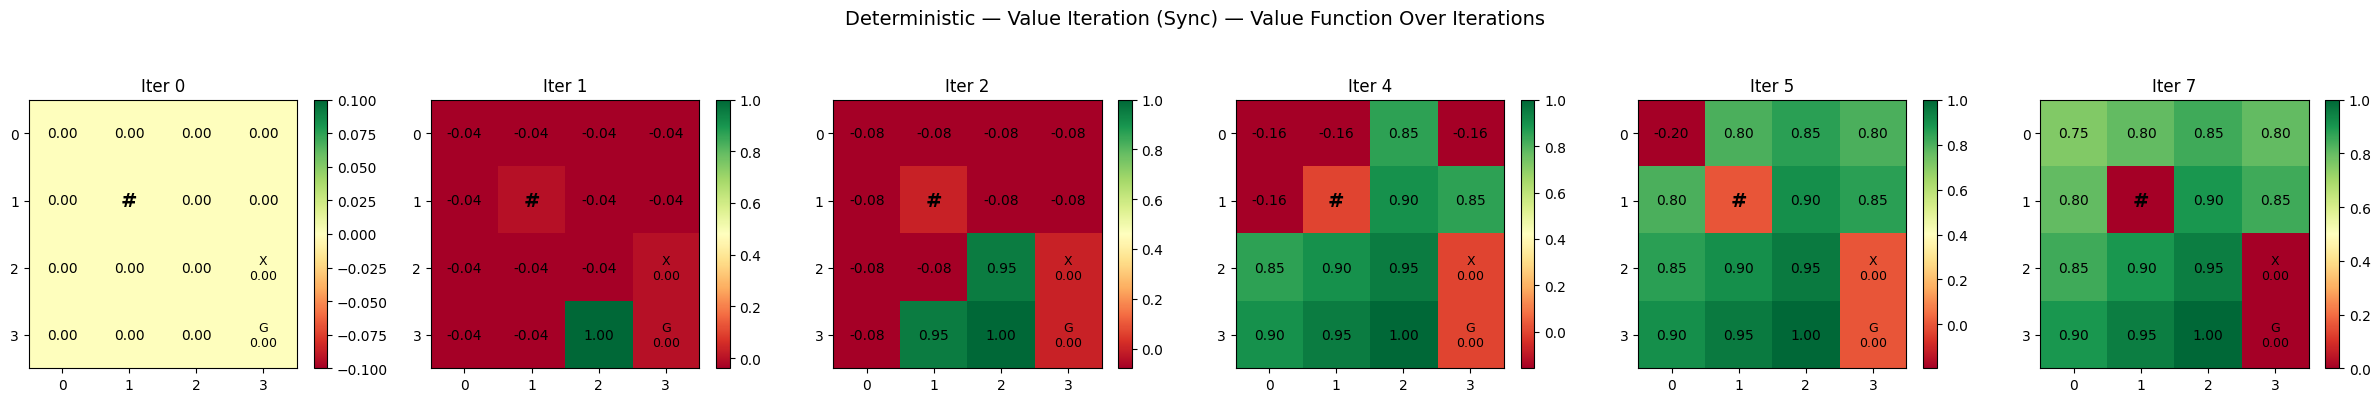

In [8]:
# --- Value function heatmaps over iterations (Value Iteration, synchronous) ---
plot_value_history(vi_sync_h, env_det, title_prefix="Deterministic — Value Iteration (Sync)")

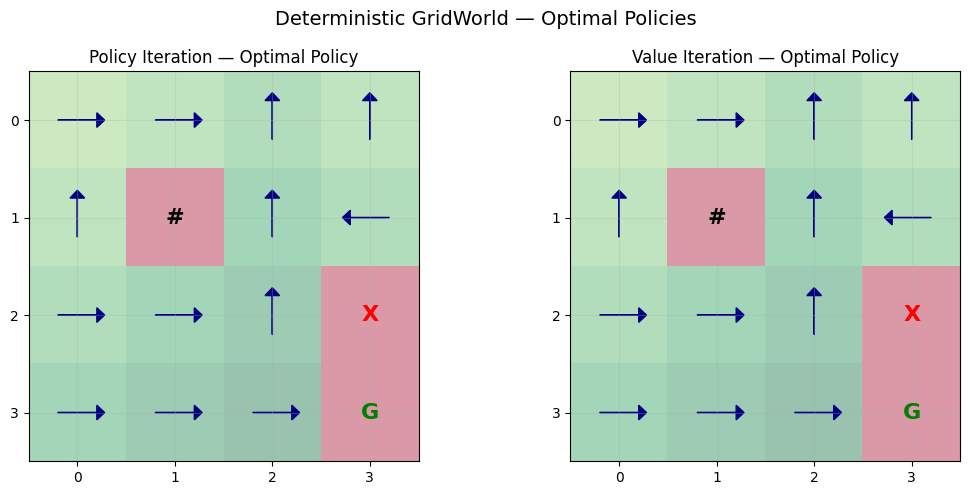

In [9]:
# --- Optimal policy arrows for deterministic GridWorld ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_policy_arrows(pi_sync_pol, env_det, V=pi_sync_V, title="Policy Iteration — Optimal Policy", ax=axes[0])
plot_policy_arrows(vi_sync_pol, env_det, V=vi_sync_V, title="Value Iteration — Optimal Policy", ax=axes[1])
fig.suptitle("Deterministic GridWorld — Optimal Policies", fontsize=14)
plt.tight_layout()
plt.show()

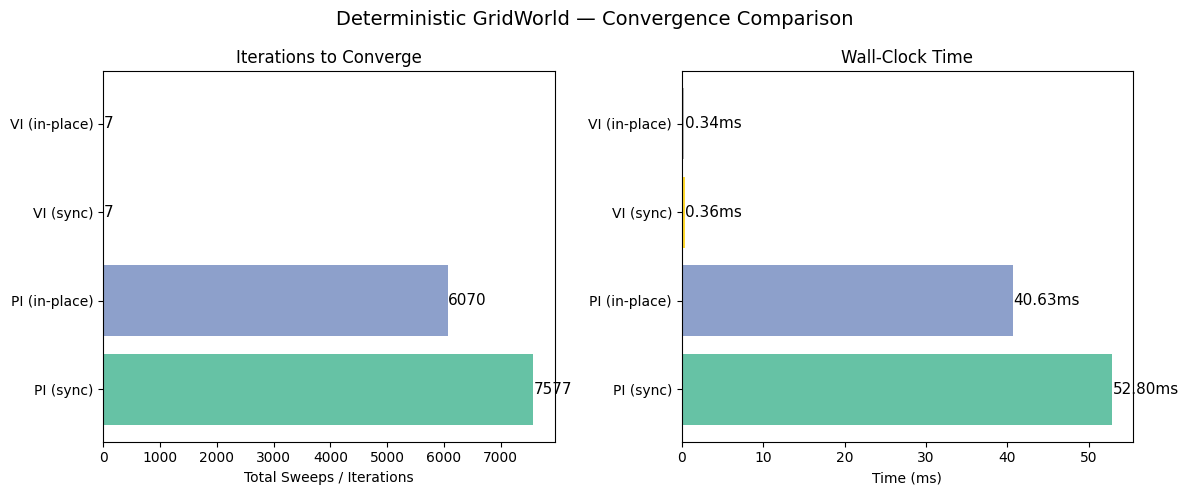

In [10]:
# --- Convergence comparison for deterministic GridWorld ---
det_results = {
    'PI (sync)':    {'iterations': pi_sync_e,  'time': pi_sync_t},
    'PI (in-place)':{'iterations': pi_ip_e,    'time': pi_ip_t},
    'VI (sync)':    {'iterations': vi_sync_it, 'time': vi_sync_t},
    'VI (in-place)':{'iterations': vi_ip_it,   'time': vi_ip_t},
}
plot_convergence_comparison(det_results, title="Deterministic GridWorld — Convergence Comparison")

---
## Part 7: Stochastic GridWorld Experiments

Same layout but with slippery transitions (80% intended, 10% each perpendicular). The stochasticity forces the algorithms to account for risk — the optimal policy may avoid paths near the trap even if they are shorter.

In [11]:
# Run all four algorithms on stochastic GridWorld
print("=== STOCHASTIC GRIDWORLD (slip_prob=0.1) ===\n")

print("--- Synchronous Policy Iteration ---")
spi_sync_pol, spi_sync_V, spi_sync_vh, spi_sync_ph, spi_sync_t, spi_sync_e = \
    policy_iteration(env_sto, gamma=0.99, in_place=False)

print("\n--- In-Place Policy Iteration ---")
spi_ip_pol, spi_ip_V, spi_ip_vh, spi_ip_ph, spi_ip_t, spi_ip_e = \
    policy_iteration(env_sto, gamma=0.99, in_place=True)

print("\n--- Synchronous Value Iteration ---")
svi_sync_pol, svi_sync_V, svi_sync_h, svi_sync_t, svi_sync_it = \
    value_iteration(env_sto, gamma=0.99, in_place=False)

print("\n--- In-Place Value Iteration ---")
svi_ip_pol, svi_ip_V, svi_ip_h, svi_ip_t, svi_ip_it = \
    value_iteration(env_sto, gamma=0.99, in_place=True)

=== STOCHASTIC GRIDWORLD (slip_prob=0.1) ===

--- Synchronous Policy Iteration ---
Policy evaluation (synchronous) converged in 1514 iterations.
Policy evaluation (synchronous) converged in 776 iterations.
Policy evaluation (synchronous) converged in 35 iterations.
Policy evaluation (synchronous) converged in 55 iterations.
Policy evaluation (synchronous) converged in 62 iterations.
Policy Iteration (synchronous): converged in 5 policy steps, 2442 total eval sweeps, 0.0266s

--- In-Place Policy Iteration ---
Policy evaluation (in-place) converged in 1409 iterations.
Policy evaluation (in-place) converged in 1389 iterations.
Policy evaluation (in-place) converged in 25 iterations.
Policy evaluation (in-place) converged in 34 iterations.
Policy evaluation (in-place) converged in 37 iterations.
Policy Iteration (in-place): converged in 5 policy steps, 2894 total eval sweeps, 0.0363s

--- Synchronous Value Iteration ---
Value Iteration (synchronous): converged in 60 iterations, 0.0045s

--

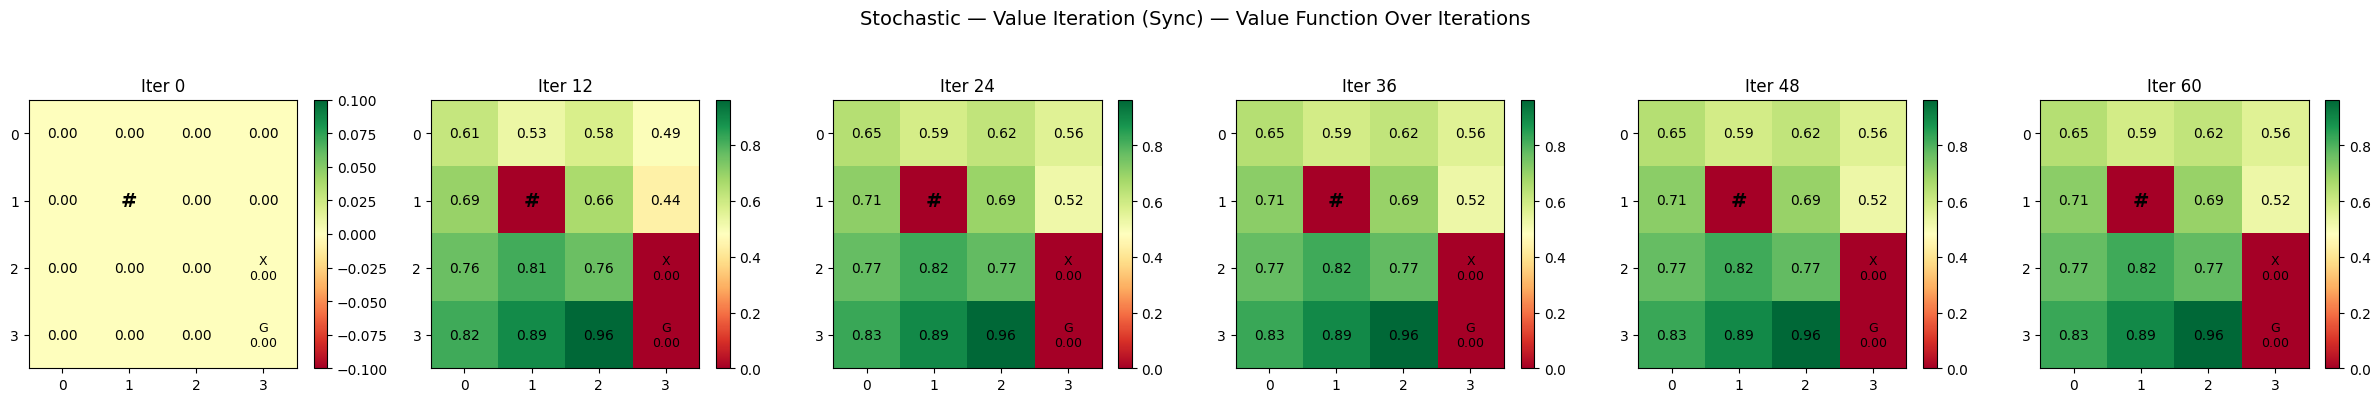

In [12]:
# --- Value function heatmaps over iterations (stochastic) ---
plot_value_history(svi_sync_h, env_sto, title_prefix="Stochastic — Value Iteration (Sync)")

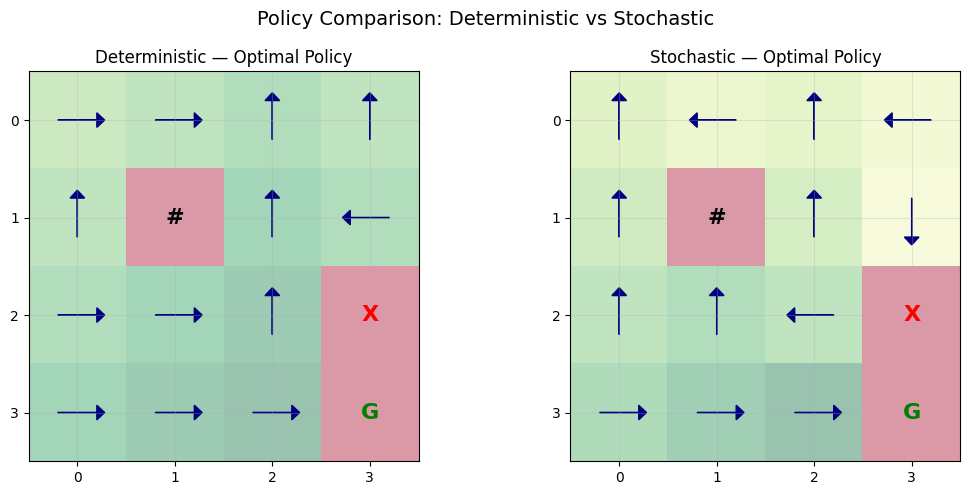

In [13]:
# --- Compare optimal policies: deterministic vs stochastic ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_policy_arrows(vi_sync_pol, env_det, V=vi_sync_V, title="Deterministic — Optimal Policy", ax=axes[0])
plot_policy_arrows(svi_sync_pol, env_sto, V=svi_sync_V, title="Stochastic — Optimal Policy", ax=axes[1])
fig.suptitle("Policy Comparison: Deterministic vs Stochastic", fontsize=14)
plt.tight_layout()
plt.show()

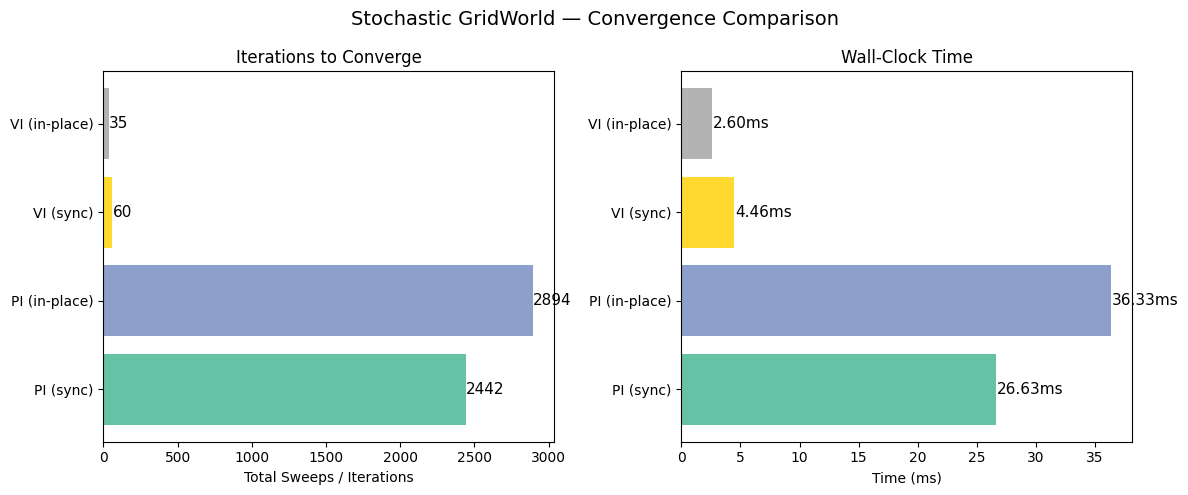

In [14]:
# --- Convergence comparison for stochastic GridWorld ---
sto_results = {
    'PI (sync)':    {'iterations': spi_sync_e,  'time': spi_sync_t},
    'PI (in-place)':{'iterations': spi_ip_e,    'time': spi_ip_t},
    'VI (sync)':    {'iterations': svi_sync_it, 'time': svi_sync_t},
    'VI (in-place)':{'iterations': svi_ip_it,   'time': svi_ip_t},
}
plot_convergence_comparison(sto_results, title="Stochastic GridWorld — Convergence Comparison")

---
## Part 8: Applying DP to Gymnasium's FrozenLake-v1

FrozenLake is a 4×4 grid where the agent must navigate from Start (S) to Goal (G) across a frozen lake with Holes (H). The ice is slippery — `is_slippery=True` makes transitions stochastic (1/3 probability for each of the three non-opposite directions).

We access the full transition model via `env.unwrapped.P` and run our DP algorithms directly on it.

In [15]:
# Create FrozenLake environment and wrap it for compatibility with our DP functions
fl_env = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=True)
fl_unwrapped = fl_env.unwrapped

# Create a lightweight adapter so our DP functions work with FrozenLake's P
class FrozenLakeAdapter:
    """Adapter to make FrozenLake compatible with our DP functions."""
    def __init__(self, env):
        self.nS = env.observation_space.n
        self.nA = env.action_space.n
        self.P = env.P
        self.rows = 4
        self.cols = 4
        self.obstacles = []
        self.goals = {15: 1.0}
        # Holes in default 4x4 map: states 5, 7, 11, 12
        self.traps = {5: 0.0, 7: 0.0, 11: 0.0, 12: 0.0}
        self.terminal_states = {5, 7, 11, 12, 15}

fl_adapter = FrozenLakeAdapter(fl_unwrapped)

# Show the FrozenLake map
print("FrozenLake-v1 (4x4, slippery):")
print(fl_unwrapped.desc.astype(str))
print(f"\nnS={fl_adapter.nS}, nA={fl_adapter.nA}")

# Inspect transition model for state 0, action RIGHT (1)
print("\nP[0][1] (state 0, action RIGHT):")
for transition in fl_adapter.P[0][1]:
    print(f"  prob={transition[0]:.4f}, next={transition[1]}, reward={transition[2]}, done={transition[3]}")

FrozenLake-v1 (4x4, slippery):
[['S' 'F' 'F' 'F']
 ['F' 'H' 'F' 'H']
 ['F' 'F' 'F' 'H']
 ['H' 'F' 'F' 'G']]

nS=16, nA=4

P[0][1] (state 0, action RIGHT):
  prob=0.3333, next=0, reward=0.0, done=False
  prob=0.3333, next=4, reward=0.0, done=False
  prob=0.3333, next=1, reward=0.0, done=False


In [16]:
# Run DP algorithms on FrozenLake
print("=== FrozenLake-v1 (Slippery) ===\n")

print("--- Policy Iteration (sync) ---")
fl_pi_pol, fl_pi_V, fl_pi_vh, fl_pi_ph, fl_pi_t, fl_pi_e = \
    policy_iteration(fl_adapter, gamma=0.99, in_place=False)

print("\n--- Value Iteration (sync) ---")
fl_vi_pol, fl_vi_V, fl_vi_h, fl_vi_t, fl_vi_it = \
    value_iteration(fl_adapter, gamma=0.99, in_place=False)

print("\nOptimal value function (FrozenLake):")
print(fl_vi_V.reshape(4, 4).round(3))

# FrozenLake actions: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP
fl_action_names = ['LEFT', 'DOWN', 'RIGHT', 'UP']
print("\nOptimal policy (FrozenLake):")
for r in range(4):
    row_str = ""
    for c in range(4):
        s = r * 4 + c
        row_str += f"{fl_action_names[fl_vi_pol[s]]:>6}"
    print(row_str)

=== FrozenLake-v1 (Slippery) ===

--- Policy Iteration (sync) ---
Policy evaluation (synchronous) converged in 1 iterations.
Policy evaluation (synchronous) converged in 33 iterations.
Policy evaluation (synchronous) converged in 163 iterations.
Policy evaluation (synchronous) converged in 173 iterations.
Policy evaluation (synchronous) converged in 348 iterations.
Policy evaluation (synchronous) converged in 370 iterations.
Policy evaluation (synchronous) converged in 441 iterations.
Policy Iteration (synchronous): converged in 7 policy steps, 1529 total eval sweeps, 0.0164s

--- Value Iteration (sync) ---
Value Iteration (synchronous): converged in 438 iterations, 0.0259s

Optimal value function (FrozenLake):
[[0.542 0.499 0.471 0.457]
 [0.558 0.    0.358 0.   ]
 [0.592 0.643 0.615 0.   ]
 [0.    0.742 0.863 0.   ]]

Optimal policy (FrozenLake):
  LEFT    UP    UP    UP
  LEFT  LEFT  LEFT  LEFT
    UP  DOWN  LEFT  LEFT
  LEFT RIGHT  DOWN  LEFT


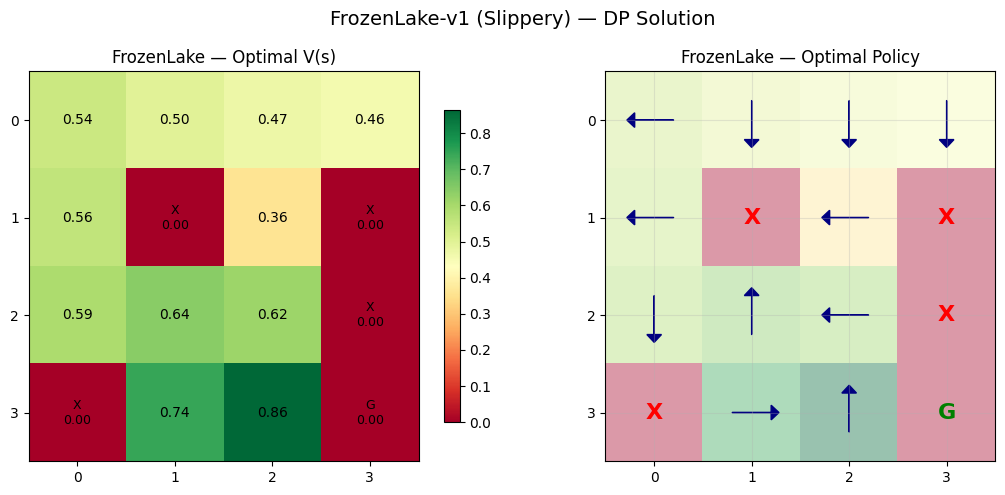

In [17]:
# --- Visualize FrozenLake results ---
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Value heatmap
plot_value_heatmap(fl_vi_V, fl_adapter, title="FrozenLake — Optimal V(s)", ax=axes[0])

# Policy arrows (note: FrozenLake uses different action mapping than our GridWorld)
# FrozenLake: 0=LEFT, 1=DOWN, 2=RIGHT, 3=UP
# Our arrow_map expects: 0=UP, 1=RIGHT, 2=DOWN, 3=LEFT
# Remap: FL_LEFT(0)->ours(3), FL_DOWN(1)->ours(2), FL_RIGHT(2)->ours(1), FL_UP(3)->ours(0)
fl_to_gw = {0: 3, 1: 2, 2: 1, 3: 0}
remapped_policy = np.array([fl_to_gw[a] for a in fl_vi_pol])
plot_policy_arrows(remapped_policy, fl_adapter, V=fl_vi_V, title="FrozenLake — Optimal Policy", ax=axes[1])

fig.suptitle("FrozenLake-v1 (Slippery) — DP Solution", fontsize=14)
plt.tight_layout()
plt.show()

---
## Part 9: Convergence Analysis & Discussion

### Summary of Results

In [18]:
# --- Summary table across all environments ---
summary_data = [
    ['Det. GridWorld',   'PI (sync)',    pi_sync_e,    f'{pi_sync_t*1000:.2f}'],
    ['Det. GridWorld',   'PI (in-place)',pi_ip_e,      f'{pi_ip_t*1000:.2f}'],
    ['Det. GridWorld',   'VI (sync)',    vi_sync_it,   f'{vi_sync_t*1000:.2f}'],
    ['Det. GridWorld',   'VI (in-place)',vi_ip_it,     f'{vi_ip_t*1000:.2f}'],
    ['Stoch. GridWorld', 'PI (sync)',    spi_sync_e,   f'{spi_sync_t*1000:.2f}'],
    ['Stoch. GridWorld', 'PI (in-place)',spi_ip_e,     f'{spi_ip_t*1000:.2f}'],
    ['Stoch. GridWorld', 'VI (sync)',    svi_sync_it,  f'{svi_sync_t*1000:.2f}'],
    ['Stoch. GridWorld', 'VI (in-place)',svi_ip_it,    f'{svi_ip_t*1000:.2f}'],
    ['FrozenLake',       'PI (sync)',    fl_pi_e,      f'{fl_pi_t*1000:.2f}'],
    ['FrozenLake',       'VI (sync)',    fl_vi_it,     f'{fl_vi_t*1000:.2f}'],
]

# Print formatted table without pandas
header = f"{'Environment':>17s}  {'Algorithm':>14s}  {'Sweeps/Iters':>12s}  {'Time (ms)':>10s}"
print(header)
print('-' * len(header))
for row in summary_data:
    print(f"{row[0]:>17s}  {row[1]:>14s}  {row[2]:>12}  {row[3]:>10s}")

      Environment       Algorithm  Sweeps/Iters   Time (ms)
-----------------------------------------------------------
   Det. GridWorld       PI (sync)          7577       52.80
   Det. GridWorld   PI (in-place)          6070       40.63
   Det. GridWorld       VI (sync)             7        0.36
   Det. GridWorld   VI (in-place)             7        0.34
 Stoch. GridWorld       PI (sync)          2442       26.63
 Stoch. GridWorld   PI (in-place)          2894       36.33
 Stoch. GridWorld       VI (sync)            60        4.46
 Stoch. GridWorld   VI (in-place)            35        2.60
       FrozenLake       PI (sync)          1529       16.42
       FrozenLake       VI (sync)           438       25.87


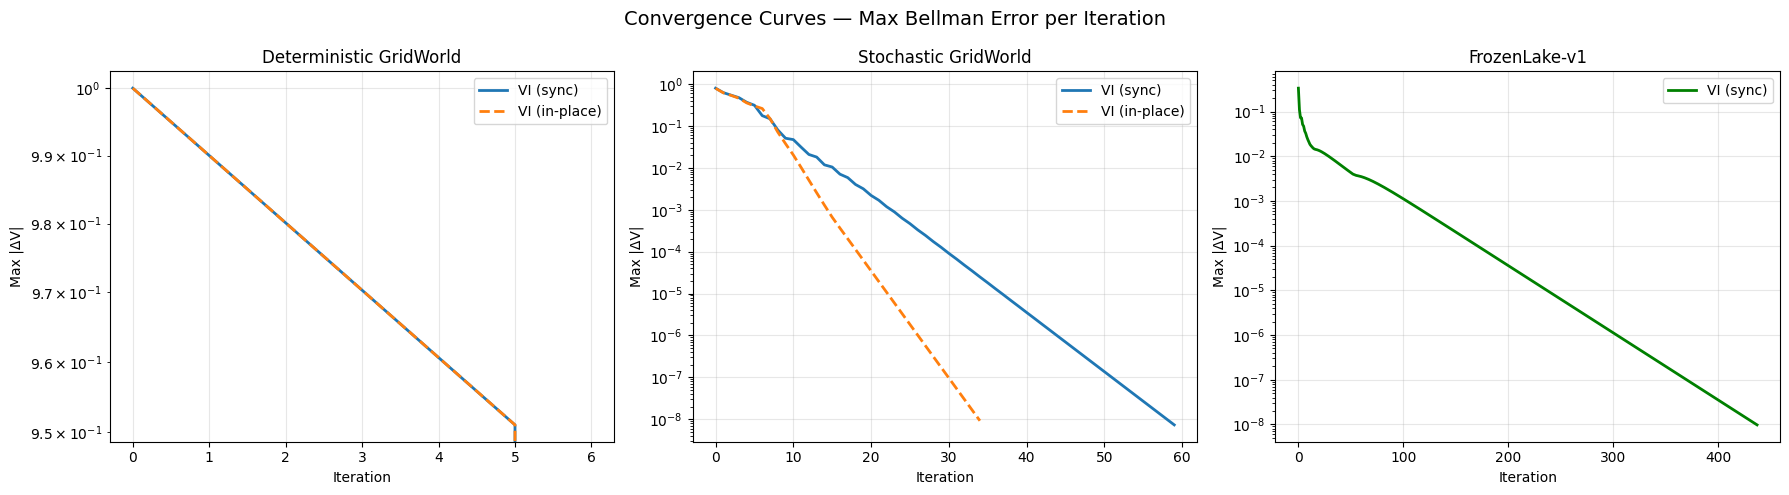

In [19]:
# --- Max delta convergence curves for VI variants ---
def compute_max_deltas(history):
    """Compute max |V_{k+1} - V_k| at each iteration from a value history."""
    deltas = []
    for i in range(1, len(history)):
        deltas.append(np.max(np.abs(history[i] - history[i-1])))
    return deltas

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Deterministic
d1 = compute_max_deltas(vi_sync_h)
d2 = compute_max_deltas(vi_ip_h)
axes[0].plot(d1, label='VI (sync)', linewidth=2)
axes[0].plot(d2, label='VI (in-place)', linewidth=2, linestyle='--')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Max |ΔV|')
axes[0].set_title('Deterministic GridWorld')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Stochastic
d3 = compute_max_deltas(svi_sync_h)
d4 = compute_max_deltas(svi_ip_h)
axes[1].plot(d3, label='VI (sync)', linewidth=2)
axes[1].plot(d4, label='VI (in-place)', linewidth=2, linestyle='--')
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Max |ΔV|')
axes[1].set_title('Stochastic GridWorld')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# FrozenLake
d5 = compute_max_deltas(fl_vi_h)
axes[2].plot(d5, label='VI (sync)', linewidth=2, color='green')
axes[2].set_yscale('log')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Max |ΔV|')
axes[2].set_title('FrozenLake-v1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle("Convergence Curves — Max Bellman Error per Iteration", fontsize=14)
plt.tight_layout()
plt.show()

### Analysis & Discussion

**1. Value Iteration vs Policy Iteration — Which converges faster?**

- **Value Iteration** typically requires fewer total sweeps than Policy Iteration on small grids. VI does one backup per state per iteration, while PI must run policy evaluation to convergence (hundreds of sweeps) at each policy step. Although PI needs very few policy improvement steps (often 3–5), each step's evaluation is expensive.
- On **larger or more complex environments**, PI can become more competitive because the policy typically stabilizes in very few steps, and the Bellman equation converges quickly under a fixed policy. But for our 4×4 grids, VI wins on total sweeps.

**2. Synchronous vs In-Place Updates**

- **In-place** updates consistently converge in fewer iterations than synchronous. This is because updated values propagate immediately within the same sweep — a state that has already been updated in the current sweep provides a more accurate estimate to its neighbors.
- The convergence curves confirm this: the in-place variant's max Bellman error drops faster in early iterations.

**3. Deterministic vs Stochastic Environments**

- Both algorithms converge in **more iterations** under stochastic dynamics. The uncertainty in transitions means value information spreads more slowly — each update mixes multiple possible next states rather than committing to one.
- The **optimal policies differ** between deterministic and stochastic settings. In the stochastic case, the policy tends to avoid paths adjacent to the trap because slipping could push the agent into it. The agent takes safer, sometimes longer routes.

**4. FrozenLake-v1**

- FrozenLake's strong stochasticity (uniform 1/3 split across 3 directions) makes it harder to solve. The optimal values are lower overall because there is significant probability of falling into holes regardless of the policy.
- The optimal policy shows counter-intuitive actions at some states — this is because the agent is playing the probabilities: choosing a direction such that the combined effect of all three possible outcomes is best, even if the "intended" direction seems wrong.

**5. When is DP Applicable?**

DP requires the **full transition model** P(s',r|s,a). This works for:
- Environments with known dynamics (games, planning problems)
- Small discrete state/action spaces (tabular representation)

DP is **not applicable** when:
- The model is unknown (must use model-free methods like MC or TD learning)
- State/action spaces are large or continuous (curse of dimensionality)
- The environment changes over time (non-stationary dynamics)

**6. Generalized Policy Iteration (GPI)**

Both PI and VI are instances of the GPI framework — they alternate between evaluation (computing values) and improvement (making the policy greedy). PI does full evaluation before each improvement step; VI does a single evaluation sweep with immediate improvement. Any interleaving converges to the optimal policy, which is why both algorithms find the same solution.